# Calibration

**This notebook assesses calibration performance of the gradient boosted survival model and recalibrates predictions using isotonic regression.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/gb_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180', 'psurv_365']]

In [4]:
survival_predictions_df.shape

(9357, 4)

In [5]:
dtype_map = pd.read_csv('../outputs/pembro_carbo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_carbo_df = pd.read_csv('../outputs/pembro_carbo_features_df.csv', dtype = dtype_map)

In [6]:
pembro_carbo_df.shape

(3706, 162)

In [7]:
df = pd.merge(pembro_carbo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(3706, 165)

In [9]:
df = df.query('adv_diagnosis_year <= 2021')

In [10]:
df.shape

(3138, 165)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.00099881, 0.316]",0.175107,0.270826,314,0.218836,0.320818
1,"(0.316, 0.502]",0.406819,0.440714,314,0.382048,0.494405
2,"(0.502, 0.622]",0.568025,0.523502,314,0.465020,0.578637
3,"(0.622, 0.697]",0.661422,0.635443,313,0.577652,0.687531
4,"(0.697, 0.746]",0.722563,0.743122,314,0.686885,0.785226
5,"(0.746, 0.782]",0.764484,0.759714,314,0.707516,0.803904
6,"(0.782, 0.81]",0.795989,0.792203,313,0.741983,0.833753
7,"(0.81, 0.837]",0.823330,0.846597,314,0.801113,0.882445
8,"(0.837, 0.865]",0.850765,0.913238,314,0.873655,0.937949
9,"(0.865, 0.928]",0.883996,0.935363,314,0.897747,0.955183


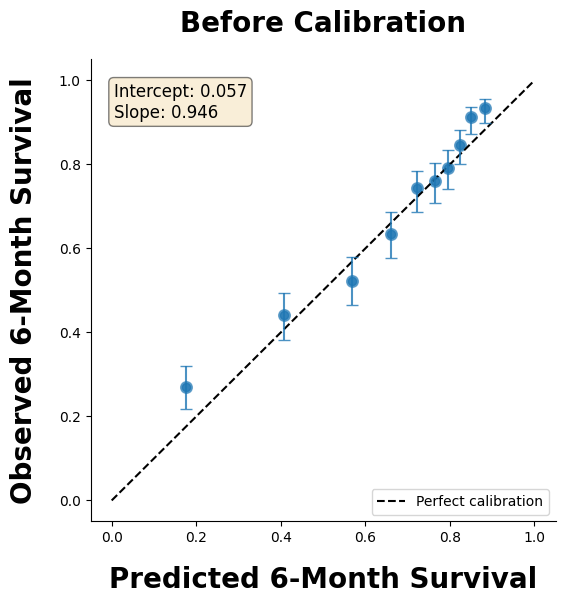

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/uncalibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')
plt.savefig('../outputs/uncalibrated_gb_6m_survival_prediction_plot.png', format = 'png', bbox_inches = 'tight')

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1884

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1705

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1613

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1745

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1672

=== Summary ===
psurv_180_calibrated computed: 3138

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1724 ± 0.0091


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/gb_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.0864, 0.35]",0.274309,0.283440,328,0.232197,0.332543
1,"(0.35, 0.49]",0.456388,0.461494,381,0.407744,0.510726
2,"(0.49, 0.611]",0.543992,0.530166,261,0.465730,0.590400
3,"(0.611, 0.699]",0.651602,0.662993,307,0.605639,0.714026
4,"(0.699, 0.744]",0.738446,0.747727,343,0.694203,0.788108
5,"(0.744, 0.791]",0.773659,0.744479,339,0.693625,0.788202
6,"(0.791, 0.831]",0.808859,0.844668,254,0.790049,0.882298
7,"(0.831, 0.869]",0.856251,0.811140,303,0.761740,0.851303
8,"(0.869, 0.928]",0.910704,0.921957,323,0.884365,0.944930
9,"(0.928, 1.0]",0.952135,0.925158,299,0.884544,0.947275


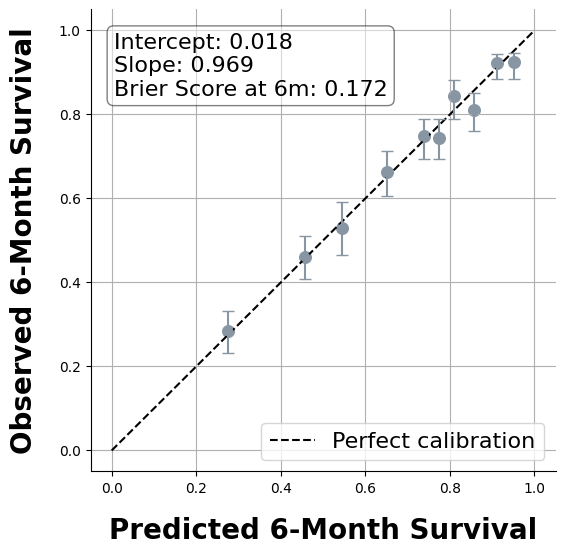

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color = '#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4         
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/calibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()